# SeamlessM4T v2 Large: Structured Compression 2.3B to ~1B

## Compression Pipeline
| Phase | Technique | Paper | Expected |
|-------|-----------|-------|----------|
| 0 | Baseline benchmark | - | reference |
| 1 | Vocabulary/Embedding pruning | Asahi (EMNLP 2023) | -200M |
| 2 | Text encoder removal (S2S-only) | Architecture analysis | -350M |
| 3 | Text decoder iterative layer pruning | Moslem (IWSLT 2025) | -150M |
| 4 | Speech encoder iterative layer pruning | ShortGPT (ACL 2025) | -150M |
| 5 | Width pruning (FLAP on FFN + heads) | FLAP (AAAI 2024) | -200M |
| 6 | T2U model pruning | Iterative layer pruning | -50M |
| 7 | Recovery fine-tuning (LoRA + S2TT CE) | Moslem (IWSLT 2025) | quality up |
| 8 | Final benchmark + paper table | - | - |

## Setup Cells 1-8
Run these at the **start of every** Kaggle session.

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil
import warnings; warnings.filterwarnings('ignore')

# ── Platform detection ────────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE  # safe assumption for this notebook
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

# ── Path layout ───────────────────────────────────────────────────────────────
# Kaggle : rclone syncs to/from gdrive:seamV5/  ←→  /kaggle/working/
# Colab  : Google Drive is mounted at /content/drive/MyDrive/
#          We work DIRECTLY inside the mounted folder — no copying, no rclone.
GDRIVE_MOUNT   = '/content/drive/MyDrive/seamV5'   # <-- your Drive folder
KAGGLE_WORK    = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK    if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'

# rclone remote root (Kaggle only — unused on Colab)
GDRIVE_ROOT = 'gdrive:seamV5'


In [2]:
# Mount Google Drive — only needed on Colab.
# On Kaggle, rclone handles the remote; skip this cell entirely there.
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted. Working folder: {GDRIVE_MOUNT}')
    # if not os.path.exists(GDRIVE_MOUNT):
    #     os.makedirs(GDRIVE_MOUNT, exist_ok=True)
    #     print(f'Created {GDRIVE_MOUNT}')
    # else:
    #     print(f'Folder exists: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')

Kaggle: skipping Drive mount.


In [3]:
for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')
print(f'Checkpts : {CKPT_DIR}')

Platform : kaggle
Work dir : /kaggle/working
Checkpts : /kaggle/working/checkpoints


In [4]:
# rclone is only needed on Kaggle. On Colab we use the mounted Drive directly.
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])
else:
    print('Colab: rclone not needed — using mounted Google Drive directly.')
    print(f'Drive path: {GDRIVE_MOUNT}')
    if not os.path.exists('/content/drive/MyDrive'):
        print('WARNING: Drive does not appear to be mounted. Run Cell 22 (drive.mount) first.')
    else:
        print('Drive mount: OK')

rclone v1.73.5


In [5]:
def _get_secret(key):
    """Fetch a secret from Kaggle Secrets or Colab userdata."""
    if ON_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(key)
        except Exception as e:
            raise RuntimeError(f'Kaggle secret {key!r} not found: {e}')
    else:
        try:
            from google.colab import userdata
            return userdata.get(key)
        except Exception as e:
            raise RuntimeError(
                f'Colab secret {key!r} not found. '
                f'Add it via the 🔑 Secrets panel in Colab: {e}')

if ON_KAGGLE:
    # rclone config is only needed on Kaggle
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root:' if r.returncode == 0 else 'rclone FAILED:')
    print(r.stdout[:300] or r.stderr[:300])
else:
    print('Colab: skipping rclone config — using mounted Drive.')
    print(f'Working directory on Drive: {WORK_DIR}')

Drive root:
           0 2026-04-11 05:42:37        -1 .ipynb_checkpoints
           0 2026-04-17 11:03:10        -1 Colab Notebooks
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-12 12:42:04        -1 cse465v5
           0 2026-04-1


In [6]:
# !rm -rf /content/drive

In [7]:
# !fusermount -u /content/drive

In [8]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
], check=True)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 38.6 MB/s eta 0:00:00
All packages installed.


In [9]:
if ON_KAGGLE:
    print('Pulling checkpoints from Google Drive via rclone...')
    r = subprocess.run(
        f'rclone sync {GDRIVE_ROOT}/checkpoints/ {CKPT_DIR}/',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'WARNING: rclone sync failed:\n{r.stderr[:300]}')
    else:
        print('rclone sync OK.')
else:
    print(f'Colab: checkpoints are on mounted Drive at {CKPT_DIR}')
    print('No sync needed — reading directly from Drive.')

files = sorted(os.listdir(CKPT_DIR)) if os.path.isdir(CKPT_DIR) else []
if files:
    print(f'{len(files)} file(s) found:')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>8.1f} MB')
else:
    print('No checkpoints yet.')

Pulling checkpoints from Google Drive via rclone...
rclone sync OK.
27 file(s) found:
  all_summaries_step000000.pt                                  0.0 MB
  phase0_baseline_step000000.pt                                0.0 MB
  phase1_benchmark_step000000.pt                               0.0 MB
  phase1_vocab_step000000.pt                                   0.1 MB
  phase3_benchmark_step000000.pt                               0.0 MB
  phase3_dec_pruning_step000000.pt                             0.0 MB
  phase4_benchmark_step000000.pt                               0.0 MB
  phase4_enc_pruning_step000000.pt                             0.0 MB
  phase5_benchmark(base)_step000000.pt                         0.0 MB
  phase5_benchmark(m4)_step000000.pt                           0.0 MB
  phase5_flap(base)_step000000.pt                              0.0 MB
  phase5_flap(m4)_step000000.pt                                0.0 MB
  phase6_benchmark_step000000.pt                               0.0 MB
  ph

In [10]:
# os.listdir('/content/drive/MyDrive/cse465v5/checkpoints')

In [11]:
import torch
from datetime import datetime

_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST = 'pruning_manifest.pt'  # optional extra metadata (e.g. T2U removal log copy)

def _rclone_push(local_path, remote_subpath):
    """Push a single file or folder to rclone remote. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab writes directly to Drive — nothing to push
    r = subprocess.run(
        f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_pull_model(stage_name):
    """Pull models/<stage_name> from rclone remote into local MODEL_DIR. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab reads directly from Drive — nothing to pull
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(
        f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

# ── Checkpoint helpers ────────────────────────────────────────────────────────

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')

    # On Kaggle, push to rclone remote so it survives session end
    if ON_KAGGLE:
        _rclone_push(path, 'checkpoints')

    # Prune old local copies
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f):
            os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive(names=None):
    if ON_KAGGLE:
        print('[ckpt] Syncing checkpoints from rclone remote...')
        r = subprocess.run(
            f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR} (no sync needed)')

    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} checkpoint(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

# ── Config sync: make config.json match actual architecture ───────────────────

def _find_layers(component):
    """Find the main transformer-layer ModuleList inside a component."""
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None


def _get_t2u_encoder_decoder(mdl):
    """SeamlessM4Tv2: stacks live under t2u_model.model.{encoder,decoder}, not t2u_model.{encoder,decoder}."""
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is None:
        return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None:
        return None, None
    enc = getattr(inner, 'encoder', None)
    dec = getattr(inner, 'decoder', None)
    return enc, dec


def _infer_t2u_layer_counts_from_checkpoint_dir(model_dir):
    """
    Infer actual T2U encoder/decoder depth from saved weights (fixes legacy saves
    where config.json still had full 6+6 layers).
    Self-contained (no load_hf_weights_dict): works in minimal notebooks and any cell order.
    Returns (enc_n, dec_n) or (None, None) if not inferable.
    """
    import os
    sd = None
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            sd = load_file(safe)
        except ImportError:
            pass
    if sd is None:
        pt = os.path.join(model_dir, 'pytorch_model.bin')
        if os.path.isfile(pt):
            blob = torch.load(pt, map_location='cpu', weights_only=False)
            if isinstance(blob, dict) and 'model' in blob:
                inner = blob['model']
                if isinstance(inner, dict):
                    sd = inner
                else:
                    sd = blob
            else:
                sd = blob
    if not sd:
        return None, None
    pref_e = 't2u_model.model.encoder.layers.'
    pref_d = 't2u_model.model.decoder.layers.'
    enc_idx, dec_idx = set(), set()
    for k in sd:
        if k.startswith(pref_e):
            rest = k[len(pref_e):].split('.', 1)[0]
            if rest.isdigit():
                enc_idx.add(int(rest))
        elif k.startswith(pref_d):
            rest = k[len(pref_d):].split('.', 1)[0]
            if rest.isdigit():
                dec_idx.add(int(rest))
    enc_n = (max(enc_idx) + 1) if enc_idx else None
    dec_n = (max(dec_idx) + 1) if dec_idx else None
    return enc_n, dec_n


def _sync_config_to_architecture(mdl):
    """
    Walk the model, count actual layers / dimensions, and update every
    config field that from_pretrained uses to build the architecture.
    This guarantees the saved config.json matches the saved weights.
    """
    cfg = mdl.config
    updates = {}

    def _set(key, new_val):
        if hasattr(cfg, key) and getattr(cfg, key) != new_val:
            updates[key] = (getattr(cfg, key), new_val)
            setattr(cfg, key, new_val)

    # ── vocab ──
    if hasattr(mdl, 'shared') and hasattr(mdl.shared, 'num_embeddings'):
        _set('vocab_size', mdl.shared.num_embeddings)

    # ── text decoder ──
    if hasattr(mdl, 'text_decoder'):
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            _set('decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('decoder_ffn_dim', first.ffn.fc1.out_features)

    # ── text encoder ──
    if hasattr(mdl, 'text_encoder'):
        layers = _find_layers(mdl.text_encoder)
        if layers is not None:
            _set('encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('encoder_ffn_dim', first.ffn.fc1.out_features)

    # ── speech encoder (nested: speech_encoder.encoder.layers etc.) ──
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        layers = None
        for parent in [enc, getattr(enc, 'encoder', None)]:
            if parent is not None:
                layers = _find_layers(parent)
                if layers is not None:
                    break
        if layers is None:
            for _, child in enc.named_children():
                layers = _find_layers(child)
                if layers is not None:
                    break
        if layers is not None:
            _set('speech_encoder_layers', len(layers))
            first = layers[0]
            for ffn_path in ['ffn', 'feed_forward']:
                ffn = getattr(first, ffn_path, None)
                if ffn is not None:
                    fc = getattr(ffn, 'intermediate_dense', getattr(ffn, 'fc1', None))
                    if fc is not None and hasattr(fc, 'out_features'):
                        _set('speech_encoder_intermediate_size', fc.out_features)
                    break

    # ── T2U model (v2 stacks: t2u_model.model.encoder / .decoder) ──
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    if t2u_enc is not None:
        layers = _find_layers(t2u_enc)
        if layers is not None:
            _set('t2u_encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('t2u_encoder_ffn_dim', first.ffn.fc1.out_features)
    if t2u_dec is not None:
        layers = _find_layers(t2u_dec)
        if layers is not None:
            _set('t2u_decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('t2u_decoder_ffn_dim', first.ffn.fc1.out_features)

    # Sub-module config uses stripped names (encoder_layers / decoder_layers)
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is not None and hasattr(t2u, 'config'):
        tc = t2u.config
        if t2u_enc is not None:
            layers = _find_layers(t2u_enc)
            if layers is not None and hasattr(tc, 'encoder_layers'):
                if getattr(tc, 'encoder_layers', None) != len(layers):
                    print(f'  t2u_model.config.encoder_layers: {getattr(tc, "encoder_layers", None)} -> {len(layers)}')
                    tc.encoder_layers = len(layers)
        if t2u_dec is not None:
            layers = _find_layers(t2u_dec)
            if layers is not None and hasattr(tc, 'decoder_layers'):
                if getattr(tc, 'decoder_layers', None) != len(layers):
                    print(f'  t2u_model.config.decoder_layers: {getattr(tc, "decoder_layers", None)} -> {len(layers)}')
                    tc.decoder_layers = len(layers)

    if updates:
        for k, (old, new) in updates.items():
            print(f'  config.{k}: {old} -> {new}')
    return updates

# ── Custom state sidecar (vocab remap, etc.) ──────────────────────────────────

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    """Save non-standard model attributes (e.g. vocab remap) as a sidecar file."""
    state = {}
    for attr in _CUSTOM_ATTR_NAMES:
        if hasattr(mdl, attr):
            state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    """Restore non-standard model attributes from the sidecar file."""
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath):
        return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items():
        setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

# ── device consolidation ──────────────────────────────────────────────────────

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split across devices by device_map='auto'."""
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device map detected, consolidating to cuda:0...')
    from accelerate.hooks import remove_hook_from_submodules
    try:
        remove_hook_from_submodules(mdl)
    except AttributeError:
        # accelerate + PeftModel: hook detach/delattr can fail on root; .to() still works
        pass
    mdl = mdl.to('cuda:0')
    if hasattr(mdl, 'hf_device_map') and isinstance(getattr(mdl, 'hf_device_map', None), dict):
        try:
            d0 = torch.device('cuda:0')
            mdl.hf_device_map = {k: d0 for k in mdl.hf_device_map}
        except Exception:
            pass
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl


# ── Model save / load ─────────────────────────────────────────────────────────

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    """
    Save model weights + processor to MODEL_DIR/<stage_name>.

    Why not torch.save(model) alone?
    - HuggingFace needs config.json, tokenizer, preprocessor_config.json,
      generation_config.json, etc. Processor + trimmed vocab (id_to_text,
      lang code maps) live outside nn.Module state_dict.
    - We therefore use save_pretrained (canonical HF layout) and add:
        * _sync_config_to_architecture + sync_model_config so layer counts
          match pruned ModuleLists (avoids MISSING / surprise init on load).
        * _custom_state.pt for non-pickled attrs (_vocab_remap_to_old).
        * pruning_manifest.pt for optional bookkeeping (e.g. T2u removal log).

    manifest_extra: optional dict merged into pruning_manifest.pt (e.g.
        {'t2u_removed': all_removed} for Phase 6).
    """
    target_dir = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target_dir, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target_dir} ...')

    _sync_config_to_architecture(mdl)
    try:
        sync_model_config(mdl)
    except Exception as e:
        print(f'  [model] sync_model_config skipped: {e}')
    _save_custom_state(mdl, target_dir)

    man = {'stage_name': stage_name}
    if manifest_extra:
        man.update(manifest_extra)
    torch.save(man, os.path.join(target_dir, _PRUNING_MANIFEST))
    print(f'  Saved {_PRUNING_MANIFEST} keys={list(man.keys())}')

    try:
        mdl.save_pretrained(target_dir, safe_serialization=True)
    except Exception as e:
        print(f'  [model] safe_serialization failed ({e}); saving .bin')
        mdl.save_pretrained(target_dir)
    proc.save_pretrained(target_dir)

    total = sum(os.path.getsize(f'{target_dir}/{f}')
                for f in os.listdir(target_dir)) / 1e6
    print(f'[model] Local save done. {total:.0f} MB in {len(os.listdir(target_dir))} files.')

    if ON_KAGGLE:
        print(f'[model] Pushing to rclone remote...')
        r = subprocess.run(
            f'rclone sync "{target_dir}/" "{GDRIVE_ROOT}/models/{stage_name}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING: rclone push failed: {r.stderr[:300]}')
        else:
            rv = subprocess.run(
                f'rclone ls "{GDRIVE_ROOT}/models/{stage_name}/"',
                shell=True, capture_output=True, text=True)
            n_remote = len(rv.stdout.strip().splitlines()) if rv.stdout.strip() else 0
            print(f'[model] Verified {n_remote} files on remote.')
    else:
        print(f'[model] Colab: saved directly to Drive. No additional sync needed.')


def load_hf_weights_dict(model_dir):
    """Load flat state_dict from HF save (safetensors or pytorch_model.bin)."""
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            return load_file(safe)
        except ImportError:
            print('  [model] safetensors not installed; cannot read model.safetensors')
    pt = os.path.join(model_dir, 'pytorch_model.bin')
    if os.path.isfile(pt):
        blob = torch.load(pt, map_location='cpu', weights_only=False)
        if isinstance(blob, dict) and 'model' in blob:
            inner = blob['model']
            if isinstance(inner, dict):
                return inner
        return blob
    return None


def load_model_from_drive(stage_name):
    """
    Load a model from MODEL_DIR/<stage_name>.
    - Colab:  reads directly from mounted Drive.
    - Kaggle: checks local cache first; pulls from rclone remote if missing.
    """
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
    local = f'{MODEL_DIR}/{stage_name}'

    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache, pulling from remote...')
        _rclone_pull_model(stage_name)

    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Path not found or empty: {local}')

    weight_files = [f for f in os.listdir(local)
                    if f.endswith('.safetensors') or f.endswith('.bin')]
    if not weight_files:
        raise RuntimeError(f'[model] No weight files in {local}')

    print(f'[model] Loading {stage_name} from {local} ...')
    from transformers import AutoConfig
    cfg = AutoConfig.from_pretrained(local)
    enc_n, dec_n = _infer_t2u_layer_counts_from_checkpoint_dir(local)
    if enc_n is not None and getattr(cfg, 't2u_encoder_layers', None) != enc_n:
        print(f'  [model] Repair T2U encoder depth from weights: {cfg.t2u_encoder_layers} -> {enc_n}')
        cfg.t2u_encoder_layers = enc_n
    if dec_n is not None and getattr(cfg, 't2u_decoder_layers', None) != dec_n:
        print(f'  [model] Repair T2U decoder depth from weights: {cfg.t2u_decoder_layers} -> {dec_n}')
        cfg.t2u_decoder_layers = dec_n
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, config=cfg, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    pm = os.path.join(local, _PRUNING_MANIFEST)
    if os.path.isfile(pm):
        meta = torch.load(pm, map_location='cpu', weights_only=False)
        print(f'  [model] pruning_manifest: {list(meta.keys())}')
    mdl.eval()
    return mdl, proc

print('I/O helpers ready.')
print(f'  Platform  : {PLATFORM}')
print(f'  Model dir : {MODEL_DIR}')
print(f'  Ckpt dir  : {CKPT_DIR}')
if ON_KAGGLE:
    print(f'  rclone    : {GDRIVE_ROOT}')
else:
    print(f'  Drive     : mounted at /content/drive, working in {GDRIVE_MOUNT}')


I/O helpers ready.
  Platform  : kaggle
  Model dir : /kaggle/working/models
  Ckpt dir  : /kaggle/working/checkpoints
  rclone    : gdrive:seamV5


In [12]:
sync_checkpoints_from_drive()

[ckpt] Syncing checkpoints from rclone remote...
[ckpt] 27 checkpoint(s) available
  all_summaries_step000000.pt                                 0.0 MB
  phase0_baseline_step000000.pt                               0.0 MB
  phase1_benchmark_step000000.pt                              0.0 MB
  phase1_vocab_step000000.pt                                  0.1 MB
  phase3_benchmark_step000000.pt                              0.0 MB
  phase3_dec_pruning_step000000.pt                            0.0 MB
  phase4_benchmark_step000000.pt                              0.0 MB
  phase4_enc_pruning_step000000.pt                            0.0 MB
  phase5_benchmark(base)_step000000.pt                        0.0 MB
  phase5_benchmark(m4)_step000000.pt                          0.0 MB
  phase5_flap(base)_step000000.pt                             0.0 MB
  phase5_flap(m4)_step000000.pt                               0.0 MB
  phase6_benchmark_step000000.pt                              0.0 MB
  phase6_t2u_pruning

In [13]:
def save_figure(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}', dpi=150, bbox_inches='tight')
    if ON_KAGGLE:
        _rclone_push(f'{FIG_DIR}/{name}', 'figures')

import torchaudio, numpy as np
from IPython.display import Audio as IPAudio, display

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename, label=''):
    path = f'{AUDIO_DIR}/{filename}'
    if hasattr(audio, 'numpy'): t = audio.squeeze().unsqueeze(0).float()
    else: t = torch.tensor(audio).unsqueeze(0).float()
    torchaudio.save(path, t, sr)
    mb = os.path.getsize(path) / 1e6
    print(f'[audio] Saved {filename} ({mb:.1f} MB)')

print('Audio helpers ready.')

Audio helpers ready.


In [14]:
import os
import glob
import torch
from datetime import datetime

def session_status():
    print('=' * 60)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')

    # Gathering files from the checkpoint directory
    if os.path.exists(CKPT_DIR):
        local_files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) if os.path.isfile(f)]
        print(f'  Checkpoint files in {CKPT_DIR}: {len(local_files)}')
        for f in sorted(local_files)[:20]:
            rel_path = os.path.relpath(f, CKPT_DIR)
            print(f'    {rel_path:<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    else:
        print(f'  Directory not found: {CKPT_DIR}')

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}')
        print(f'  VRAM: {props.total_memory / 1e9:.1f} GB')

    print('=' * 60)

session_status()

  Platform : kaggle   Time : 2026-04-19 18:26
  Checkpoint files in /kaggle/working/checkpoints: 27
    all_summaries_step000000.pt                             0.0 MB
    phase0_baseline_step000000.pt                           0.0 MB
    phase1_benchmark_step000000.pt                          0.0 MB
    phase1_vocab_step000000.pt                              0.1 MB
    phase3_benchmark_step000000.pt                          0.0 MB
    phase3_dec_pruning_step000000.pt                        0.0 MB
    phase4_benchmark_step000000.pt                          0.0 MB
    phase4_enc_pruning_step000000.pt                        0.0 MB
    phase5_benchmark(base)_step000000.pt                    0.0 MB
    phase5_benchmark(m4)_step000000.pt                      0.0 MB
    phase5_flap(base)_step000000.pt                         0.0 MB
    phase5_flap(m4)_step000000.pt                           0.0 MB
    phase6_benchmark_step000000.pt                          0.0 MB
    phase6_t2u_pruning_step00

## Core Library: Model, Benchmark, Plotting

In [15]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {}
    for name, child in model.named_children():
        bd[name] = count_params(child)
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved() / 1e9
        print(f'  GPU mem: {a:.2f} GB alloc / {r:.2f} GB reserved')

print('Core utilities ready.')

Core utilities ready.


In [16]:
# CORE CELL
# ── MMS-ASR setup (Bengali ASR for ASR-BLEU metric) ─────────────────────────
# facebook/mms-1b-all uses Wav2Vec2ForCTC + adapter per language.
# Bengali ISO-639-3 code = "ben" (same as SeamlessM4T's tgt_lang).
# Load once, reuse across all benchmark calls.
 
import gc as _stdlib_gc
 
_MMS_MODEL_ID = "facebook/mms-1b-all"
_MMS_LANG     = "ben"   # Bengali ISO-639-3
 
_mms_asr_model     = None
_mms_asr_processor = None
 
def _ensure_mms_loaded():
    """Lazy-load MMS ASR model and Bengali adapter. Cached after first call."""
    global _mms_asr_model, _mms_asr_processor
    if _mms_asr_model is not None:
        return
    from transformers import Wav2Vec2ForCTC, AutoProcessor
    print(f"[MMS-ASR] Loading {_MMS_MODEL_ID}  lang={_MMS_LANG}...")
    _mms_asr_processor = AutoProcessor.from_pretrained(
        _MMS_MODEL_ID, target_lang=_MMS_LANG
    )
    _mms_asr_model = Wav2Vec2ForCTC.from_pretrained(
        _MMS_MODEL_ID,
        target_lang=_MMS_LANG,
        ignore_mismatched_sizes=True,
        torch_dtype=torch.float16,
    )
    _mms_asr_model.load_adapter(_MMS_LANG)
    _mms_asr_model = _mms_asr_model.eval()
    # Keep MMS on CPU to not fight for VRAM with the main model.
    # Move to cuda only if there is room; otherwise keep on CPU (slower but safe).
    try:
        _mms_asr_model = _mms_asr_model.to("cuda:0")
    except RuntimeError:
        pass
    print("[MMS-ASR] Ready.")
 
 
def asr_transcribe(audio_np, sr=16000):
    """
    Transcribe Bengali audio with MMS ASR (facebook/mms-1b-all).
    audio_np: numpy float32 array at 16 kHz.
    Returns: transcription string.
    """
    _ensure_mms_loaded()
    if audio_np is None or len(audio_np) < 400:
        return ""
    import torchaudio
    # Resample if needed
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000
        ).numpy()
    device = next(_mms_asr_model.parameters()).device
    inputs = _mms_asr_processor(
        audio_np, sampling_rate=16000, return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = _mms_asr_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return _mms_asr_processor.batch_decode(pred_ids)[0].strip()
 
 
def compute_asr_bleu(audio_np, ref_text, sr=16000):
    """
    ASR-BLEU: transcribe audio with MMS → BLEU against reference text.
    Returns (asr_text, bleu_score).
    """
    try:
        hyp = asr_transcribe(audio_np, sr)
        bleu = compute_bleu(hyp, ref_text) if hyp.strip() else 0.0
        return hyp, bleu
    except Exception as e:
        return "", 0.0
 
 
def compute_asr_chrf(audio_np, ref_text, sr=16000):
    """ASR-ChrF: transcribe audio → ChrF against reference text."""
    try:
        hyp = asr_transcribe(audio_np, sr)
        return hyp, compute_chrf(hyp, ref_text) if hyp.strip() else 0.0
    except Exception:
        return "", 0.0
 
 
print("MMS-ASR helpers ready  (lazy-loaded on first use).")

MMS-ASR helpers ready  (lazy-loaded on first use).


In [17]:
from sacrebleu.metrics import BLEU, CHRF

_bleu = BLEU(effective_order=True)
_chrf = CHRF()


def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    """Remap trimmed vocab IDs back to original IDs for tokenizer decoding."""
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    """Device where speech inputs should be placed (first speech encoder param)."""
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full S2ST: returns (text, audio_numpy). Falls back to text-only if vocoder fails."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            # Vocoder fails when T2U produces a very short unit sequence (<3 units).
            # Fall back to text-only to still get BLEU/ChrF for this sample.
            print("failed running s2tonly")
            text = run_s2t_only(mdl, wav, tgt_lang)
            return text, np.zeros(16000)

# ── Add this function to Cell 13 (alongside run_s2t_only) ────────────────────

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}

    orig_voc = mdl.vocoder
    inp_device = next(iter(inputs.values())).device

    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs):
            return torch.zeros(1, 1, device=inp_device), [1]

    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc

    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]


def sync_model_config(mdl):
    """
    After structural pruning, sync config layer counts to actual module counts.
    Without this, generate()'s beam search indexes past_key_values by layer
    number from config and throws IndexError when layers have been removed.
    """
    # Speech encoder (SeamlessM4Tv2 uses flat config.speech_encoder_layers)
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            if hasattr(mdl.config, 'speech_encoder_layers'):
                old = mdl.config.speech_encoder_layers
                if old != actual:
                    mdl.config.speech_encoder_layers = actual
                    print(f'  [config] speech_encoder_layers: {old} -> {actual}')
            if hasattr(mdl.config, 'speech_encoder_config') and hasattr(
                    mdl.config.speech_encoder_config, 'num_hidden_layers'):
                old = mdl.config.speech_encoder_config.num_hidden_layers
                if old != actual:
                    mdl.config.speech_encoder_config.num_hidden_layers = actual
                    print(f'  [config] speech_encoder_config.num_hidden_layers: {old} -> {actual}')
            subcfg = getattr(mdl.speech_encoder, 'config', None)
            if subcfg is not None and hasattr(subcfg, 'num_hidden_layers'):
                old2 = subcfg.num_hidden_layers
                if old2 != actual:
                    subcfg.num_hidden_layers = actual
                    print(f'  [config] speech_encoder.config.num_hidden_layers: {old2} -> {actual}')

    # Text decoder
    if hasattr(mdl, 'text_decoder'):
        dec = mdl.text_decoder
        la = find_layers_attr(dec)
        if la:
            actual = len(getattr(dec, la))
            if hasattr(mdl.config, 'decoder_layers'):
                old = mdl.config.decoder_layers
                if old != actual:
                    mdl.config.decoder_layers = actual
                    print(f'  [config] decoder_layers: {old} -> {actual}')
            # also patch text_decoder config if it has its own
            if hasattr(dec, 'config') and hasattr(dec.config, 'decoder_layers'):
                dec.config.decoder_layers = actual

    # T2U model (v2: t2u_model.model.encoder / .decoder)
    if hasattr(mdl, 't2u_model'):
        t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
        for sub, comp, cfg_key in [
            ('encoder', t2u_enc, 't2u_encoder_layers'),
            ('decoder', t2u_dec, 't2u_decoder_layers'),
        ]:
            if comp is None:
                continue
            la = find_layers_attr(comp)
            if la:
                actual = len(getattr(comp, la))
                if hasattr(mdl.config, cfg_key):
                    old = getattr(mdl.config, cfg_key)
                    if old != actual:
                        setattr(mdl.config, cfg_key, actual)
                        print(f'  [config] {cfg_key}: {old} -> {actual}')
        t2u = mdl.t2u_model
        if hasattr(t2u, 'config'):
            tc = t2u.config
            if t2u_enc is not None:
                la = find_layers_attr(t2u_enc)
                if la and hasattr(tc, 'encoder_layers'):
                    actual = len(getattr(t2u_enc, la))
                    old = getattr(tc, 'encoder_layers', None)
                    if old != actual:
                        tc.encoder_layers = actual
                        print(f'  [config] t2u_model.config.encoder_layers: {old} -> {actual}')
            if t2u_dec is not None:
                la = find_layers_attr(t2u_dec)
                if la and hasattr(tc, 'decoder_layers'):
                    actual = len(getattr(t2u_dec, la))
                    old = getattr(tc, 'decoder_layers', None)
                    if old != actual:
                        tc.decoder_layers = actual
                        print(f'  [config] t2u_model.config.decoder_layers: {old} -> {actual}')

    print('  [config] sync done.')

def remap_label_ids(token_ids, mdl):
    """
    Map tokenizer output IDs (original tokenizer space) -> trimmed model embedding space.
    Supports [seq_len] or [batch, seq_len]. Positions already -100 stay -100.
    """
    if not hasattr(mdl, '_vocab_remap_to_old'):
        return token_ids
    remap = mdl._vocab_remap_to_old
    old_to_new = {old.item(): new for new, old in enumerate(remap)}
    if token_ids.dim() == 1:
        return torch.tensor(
            [(-100 if t in (-100, -1) else old_to_new.get(t, -100))
             for t in token_ids.tolist()],
            dtype=token_ids.dtype, device=token_ids.device)
    out = token_ids.clone()
    for bi in range(out.shape[0]):
        for j in range(out.shape[1]):
            t = out[bi, j].item()
            if t in (-100, -1):
                continue
            out[bi, j] = old_to_new.get(t, -100)
    return out

def run_benchmark(mdl, samples, label='model', tgt_lang='ben', save_n=4):
    """
    Benchmark using text-only generation for BLEU/ChrF/RTF (fast, no vocoder).
    Full S2ST is only run for the first save_n samples to save audio clips.
    RTF reflects the speech-encoder + text-decoder cost, which is what matters
    for quality-per-compute comparisons across pruning phases.
    """
    print(f'\n{"="*60}\n  BENCHMARK: {label}\n  Samples: {len(samples)}  Target: {tgt_lang}\n{"="*60}\n')
    gpu_mem()
    results = []
    for i, s in enumerate(samples):
        try:
            dur = len(s['wav']) / 16000
            t0 = time.time()
            pred_text = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf  = elapsed / dur
            bleu = compute_bleu(pred_text, s['ref'])
            chrf = compute_chrf(pred_text, s['ref'])
            print(f'  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}  id={s["id"]}')
            print(f'              pred: {pred_text[:80]}')
            if save_n > 0 and i < save_n:
                _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                save_audio(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                play(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                save_audio(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
                play(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
            results.append(dict(id=s['id'], bleu=bleu, chrf=chrf, rtf=rtf, pred=pred_text, ref=s['ref']))
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'  [{i+1:>2}/{len(samples)}] ERROR: {e}')
            results.append(dict(id=s['id'], bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r['rtf'] for r in valid])) if valid else 0,
        params_M=count_params(mdl))
    print(f'\n  Summary: BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M\n')
    return results, summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_samples=10):
    """Fast ChrF eval (text-only). For iterative pruning decisions."""
    scores = []
    for s in samples[:max_samples]:
        try: scores.append(compute_chrf(run_s2t_only(mdl, s['wav'], tgt_lang), s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores))

print('Benchmark functions ready.')


Benchmark functions ready.


In [18]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

# Login to HuggingFace only if token is available (needed on Kaggle; Colab may cache it)
try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('Logged into HuggingFace Hub.')
except Exception as e:
    print(f'HF login skipped (token not found or already cached): {e}')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'

def load_base_model():
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model  -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    return mdl, proc

print('load_base_model() ready.')

Logged into HuggingFace Hub.
load_base_model() ready.


In [19]:
def _load_summaries_from_drive():
    """Pull the summary ledger from Drive once at session start."""
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES: dict = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    """Upsert by label: insert new or update existing, then persist to Drive."""
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    ordered = list(ALL_SUMMARIES.values())
    save_checkpoint({'summaries': ordered}, name='all_summaries', step=0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    """Return summaries as an ordered list (by label) for plotting."""
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Compression Pipeline: Phase Comparison', fontsize=15, fontweight='bold')
    metrics = [('avg_bleu', 'BLEU (higher=better)', '#2196F3'),
               ('avg_chrf', 'ChrF (higher=better)', '#4CAF50'),
               ('avg_rtf',  'RTF (lower=faster)', '#FF9800'),
               ('params_M', 'Parameters (M)', '#9C27B0')]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_size_vs_quality(summaries=None, save_name='size_vs_quality.png'):
    data = summaries or get_summaries()
    if not data: return
    fig, ax = plt.subplots(figsize=(10, 7))
    params = [s['params_M'] for s in data]
    bleu = [s['avg_bleu'] for s in data]
    chrf = [s['avg_chrf'] for s in data]
    ax.scatter(params, bleu, s=120, c='#2196F3', zorder=5, label='BLEU')
    ax.scatter(params, chrf, s=120, c='#4CAF50', marker='s', zorder=5, label='ChrF')
    for i, lbl in enumerate([s['label'] for s in data]):
        ax.annotate(lbl, (params[i], bleu[i]), fontsize=7, xytext=(5,5), textcoords='offset points')
    ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
    ax.set_title('Model Size vs Translation Quality', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_layer_scores(scores_dict, title='Layer Importance', save_name=None):
    indices = sorted(scores_dict.keys())
    vals = [scores_dict[i] for i in indices]
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#d32f2f' if v > np.percentile(vals, 75) else '#ff9800' if v > np.percentile(vals, 50) else '#4caf50' if v > np.percentile(vals, 25) else '#90caf9' for v in vals]
    ax.bar(indices, vals, color=colors, edgecolor='white')
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold'); ax.set_xticks(indices)
    plt.tight_layout()
    if save_name: plt.savefig(f'{FIG_DIR}/{save_name}')
    plt.show()

print('Plotting helpers ready.')

[ckpt] Loaded all_summaries_step000000.pt
Loaded 8 existing summaries: ['P0_Baseline', 'P1_VocabTrim', 'P3_DecPrune', 'P4_EncPrune', 'P5_FLAP(base)', 'P5_FLAP(m4)', 'P6_T2UIter', 'P7_DoRA']
Plotting helpers ready.


---
# Phase 0: Baseline Benchmark
Load the full teacher model, measure size and translation quality.

In [20]:
## Dataset loading
LOCAL_PARQUET_CACHE = "/kaggle/input/datasets/coderayed/fleurs-en-bn-parquet"

import concurrent.futures

BASE_PARQUET_URL = (
    "https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet"
)

def _list_parquet_urls(lang, split):
    return [f"{BASE_PARQUET_URL}/{lang}/{split}/0000.parquet?download=true"]

def _download_shard(args):
    import requests
    url, dest = args
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 1024 * 1024:
        return url, True, "cached"
    dest.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(3):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                    if chunk: f.write(chunk)
            if dest.stat().st_size < 1024 * 1024:
                raise RuntimeError("Downloaded file too small")
            return url, True, "downloaded"
        except Exception as e:
            if dest.exists(): dest.unlink()
            if attempt == 2: return url, False, str(e)
    return url, False, "unknown error"

def load_fleurs_parallel(src_lang, tgt_lang, split="train", n_workers=4):
    import pandas as pd
    from datasets import Dataset
    tasks = []
    for lang in [src_lang, tgt_lang]:
        urls = _list_parquet_urls(lang, split)
        for i, url in enumerate(urls):
            dest = f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_{i:04d}.parquet"
            tasks.append((url, dest))
    print(f"[Parallel] Downloading {len(tasks)} shards...")
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        for url, ok, msg in pool.map(_download_shard, tasks):
            print(f"  {'OK' if ok else 'FAIL'}: {msg}")
    def _load_lang(lang):
        files = sorted(glob.glob(f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet"))
        if not files: raise FileNotFoundError(f"No cached shards for {lang}")
        return Dataset.from_pandas(pd.read_parquet(files[0]))
    return _load_lang(src_lang), _load_lang(tgt_lang)

DRIVE_FLEURS_PATH = f'{GDRIVE_ROOT}/fleurs_parquet'

def push_fleurs_to_drive():
    if not ON_KAGGLE: return
    print(f'Pushing parquet cache to Drive...')
    subprocess.run(
        f'rclone copy "{LOCAL_PARQUET_CACHE}/" "{DRIVE_FLEURS_PATH}/" --transfers=8',
        shell=True, capture_output=True, text=True)

def load_fleurs_from_drive(src_lang, tgt_lang, split='train'):
    import pandas as pd
    from datasets import Dataset
    if not ON_KAGGLE:
        print('[Drive] rclone only on Kaggle.')
        return None, None
    print(f'[Drive] Pulling FLEURS parquet...')
    if not os.path.exists(LOCAL_PARQUET_CACHE):
        r = subprocess.run(
            f'rclone copy "{DRIVE_FLEURS_PATH}/" "{LOCAL_PARQUET_CACHE}/" --transfers=8',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            return None, None
    def _load_lang(lang):
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: return None
        return Dataset.from_pandas(pd.concat([pd.read_parquet(f) for f in files], ignore_index=True))
    src_ds = _load_lang(src_lang)
    tgt_ds = _load_lang(tgt_lang)
    if src_ds and tgt_ds:
        print(f'[Dataset gdrive] Loaded: {len(src_ds)} src, {len(tgt_ds)} tgt')
    return src_ds, tgt_ds

print('FLEURS data loaders ready.')

FLEURS data loaders ready.


In [21]:
# ── CELL 23 REPLACEMENT: Load eval samples (EN→BN test) ──────────────────────
import numpy as np
import torch
import torchaudio
import io
import soundfile as sf
import pandas as pd

N_EVAL = 25
TARGET_LANG = "ben"
FLEURS_SRC, FLEURS_TGT = "en_us", "bn_in"

print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for benchmarking [test]")

ds_src, ds_tgt = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split="test")

if ds_src is None or ds_tgt is None:
    print("\n[Cache miss] Downloading...")
    ds_src, ds_tgt = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split="test", n_workers=8)
    push_fleurs_to_drive()

# ── CRITICAL FIX: Convert HF Dataset to pandas DataFrame ─────────────────────
# HF Dataset iteration is slow and memory-hungry. Convert to pandas first.
print("Converting to pandas DataFrames...")
df_src = ds_src.to_pandas() if hasattr(ds_src, 'to_pandas') else pd.DataFrame(ds_src)
df_tgt = ds_tgt.to_pandas() if hasattr(ds_tgt, 'to_pandas') else pd.DataFrame(ds_tgt)

# ── Robust audio loader (parquet stores bytes, not array dicts) ──────────────
def _load_wav(audio_cell):
    """
    audio_cell: the value of row['audio'] from a pandas DataFrame.
    Handles both HF Dataset format (dict with 'array') and parquet format (dict with 'bytes').
    """
    audio = audio_cell
    if isinstance(audio, dict) and "array" in audio:
        arr, sr = audio["array"], audio["sampling_rate"]
    elif isinstance(audio, dict) and "bytes" in audio:
        wav, sr = sf.read(io.BytesIO(audio["bytes"]))
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        arr = wav
    else:
        raise RuntimeError(f"Unsupported audio format: {list(audio.keys()) if isinstance(audio, dict) else type(audio)}")
    arr = np.array(arr, dtype=np.float32)
    if sr != 16000:
        arr = torchaudio.functional.resample(
            torch.tensor(arr), sr, 16000
        ).numpy()
    return arr

# ── ID-based inner merge — deduplicated, guaranteed unique pairs ─────────────
# Parquet shards can contain duplicate IDs. Drop duplicates first.
print("Deduplicating and merging...")
src_dedup = (
    df_src[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'en_text', 'audio': 'en_audio'})
)
tgt_dedup = (
    df_tgt[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'bn_text', 'audio': 'bn_audio'})
)

print(f"  Unique IDs — EN: {len(src_dedup)}, BN: {len(tgt_dedup)}")

merged = (
    pd.merge(src_dedup, tgt_dedup, on='id', how='inner')
    .sort_values('id')
    .reset_index(drop=True)
)

print(f"  Matched unique pairs available: {len(merged)}")

# ── Take only N_EVAL samples (CRITICAL for RAM) ──────────────────────────────
merged = merged.head(N_EVAL)
print(f"  Using {len(merged)} samples for evaluation")

# ── Build eval_samples (lazy audio loading) ──────────────────────────────────
eval_samples = []
for _, row in merged.iterrows():
    eval_samples.append(dict(
        id=row['id'],
        wav=_load_wav(row['en_audio']),  # Load audio on-demand
        ref=row['bn_text'],
        en_text=row['en_text'],
    ))

# Keep for Phase 7 Cell 5 (Bengali target audio)
common_ids = list(merged['id'])
src_by_id  = {row['id']: row for _, row in merged.iterrows()}
tgt_by_id  = {row['id']: row for _, row in merged.iterrows()}

print(f"Loaded {len(eval_samples)} eval samples.")

# Clean up large DataFrames to free RAM
del df_src, df_tgt, src_dedup, tgt_dedup, merged, ds_src, ds_tgt
gc.collect()

Loading FLEURS en_us->bn_in for benchmarking [test]
[Drive] Pulling FLEURS parquet...
[Dataset gdrive] Loaded: 647 src, 920 tgt
Converting to pandas DataFrames...
Deduplicating and merging...
  Unique IDs — EN: 350, BN: 349
  Matched unique pairs available: 349
  Using 25 samples for evaluation
Loaded 25 eval samples.


60

In [22]:
print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for fine-tuning [train]")

src_ds, tgt_ds = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split="train")

if src_ds is None or tgt_ds is None:
    print("\n[Cache miss] Downloading...")
    src_ds, tgt_ds = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split="train", n_workers=8)
    push_fleurs_to_drive()

# ── Convert to pandas for efficient merge ────────────────────────────────────
print("Converting to pandas DataFrames...")
df_src_train = src_ds.to_pandas() if hasattr(src_ds, 'to_pandas') else pd.DataFrame(src_ds)
df_tgt_train = tgt_ds.to_pandas() if hasattr(tgt_ds, 'to_pandas') else pd.DataFrame(tgt_ds)

# ── Deduplicate and merge ────────────────────────────────────────────────────
print("Deduplicating and merging training data...")
src_train_dedup = (
    df_src_train[['id', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'audio': 'en_audio'})
)
tgt_train_dedup = (
    df_tgt_train[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'bn_text', 'audio': 'bn_audio'})
)

print(f"  Unique IDs — EN: {len(src_train_dedup)}, BN: {len(tgt_train_dedup)}")

merged_train = (
    pd.merge(src_train_dedup, tgt_train_dedup, on='id', how='inner')
    .reset_index(drop=True)
)

print(f"  Matched training pairs: {len(merged_train)}")

# ── Filter out empty transcriptions ──────────────────────────────────────────
merged_train = merged_train[merged_train['bn_text'].str.strip().str.len() > 0]
print(f"  After filtering empty refs: {len(merged_train)}")

# ── Build ft_samples (lazy audio loading) ────────────────────────────────────
ft_samples = []
for _, row in merged_train.iterrows():
    ft_samples.append({
        'id': row['id'],
        'wav': _load_wav(row['en_audio']),
        'ref': row['bn_text'],
    })

print(f"Usable training samples: {len(ft_samples)}")

# Clean up
del df_src_train, df_tgt_train, src_train_dedup, tgt_train_dedup, merged_train, src_ds, tgt_ds
gc.collect()

Loading FLEURS en_us->bn_in for fine-tuning [train]
[Drive] Pulling FLEURS parquet...
[Dataset gdrive] Loaded: 2602 src, 3006 tgt
Converting to pandas DataFrames...
Deduplicating and merging training data...
  Unique IDs — EN: 1476, BN: 1482
  Matched training pairs: 1449
  After filtering empty refs: 1449
Usable training samples: 1449


0

In [23]:
# model_p7_merged, processor = load_model_from_drive('phase7_dora_merged_v1')
# print_model_breakdown(model_p7_merged, 'DoRA finetuned after Phase 7)')
# model_p7_merged = _consolidate_to_single_gpu(model_p7_merged)
# # save_model_to_drive(model_p7_merged, processor, 'phase7_dora_merged_v1')

In [24]:
base_model, processor = load_base_model()

Loading processor from facebook/seamless-m4t-v2-large...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight       | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded.
  GPU mem: 1.79 GB alloc / 1.80 GB reserved


In [25]:
print("=============== KD PHASE ===============")

=============== KD PHASE ===============


In [26]:
# ===============================================================================
# BIDIRECTIONAL TRANSLATION ANALYSIS
# Analyze layer importance for Bengali→English vs English→Bengali translation
# ===============================================================================

print("\n" + "="*80)
print("  BIDIRECTIONAL TRANSLATION & LAYER ANALYSIS (Base Model)")
print("="*80)

# Load the final model for analysis
model_analysis = base_model
model_analysis.eval()

# Prepare samples for both directions
print("Preparing bidirectional translation samples...")

# English to Bengali (already have this)
eng_to_ben_samples = eval_samples[:10]  # Use first 10 samples

# Bengali to English (reverse direction)
ben_to_eng_samples = []
for sample in eval_samples[:10]:
    # Use the Bengali reference as input, English text as reference
    ben_audio_data = tgt_by_id[sample['id']]['bn_audio']
    ben_to_eng_samples.append({
        'id': sample['id'],
        'wav': _load_wav(ben_audio_data),
        'ref': sample['en_text'],  # English as reference
        'bn_text': sample['ref']   # Bengali as input context
    })

print(f"Prepared {len(eng_to_ben_samples)} EN→BN samples")
print(f"Prepared {len(ben_to_eng_samples)} BN→EN samples")


  BIDIRECTIONAL TRANSLATION & LAYER ANALYSIS (Base Model)
Preparing bidirectional translation samples...
Prepared 10 EN→BN samples
Prepared 10 BN→EN samples


In [27]:
# ===============================================================================
# LAYER ACTIVATION ANALYSIS
# Hook into transformer layers to capture activation magnitudes
# ===============================================================================

import torch.nn.functional as F
from collections import defaultdict
import numpy as np

class LayerActivationHook:
    def __init__(self):
        self.activations = defaultdict(list)
        self.hooks = []
    
    def register_hooks(self, model, component_name):
        """Register hooks on transformer layers"""
        component = getattr(model, component_name, None)
        if component is None:
            return
        
        # Handle different layer structures
        layers = None
        if hasattr(component, 'layers'):
            layers = component.layers
        elif hasattr(component, 'encoder') and hasattr(component.encoder, 'layers'):
            layers = component.encoder.layers
        elif hasattr(component, 'model'):
            if hasattr(component.model, 'encoder') and hasattr(component.model.encoder, 'layers'):
                layers = component.model.encoder.layers
            elif hasattr(component.model, 'decoder') and hasattr(component.model.decoder, 'layers'):
                layers = component.model.decoder.layers
        
        if layers is None:
            return
        
        for i, layer in enumerate(layers):
            hook = layer.register_forward_hook(
                self.make_hook_fn(f"{component_name}_layer_{i}")
            )
            self.hooks.append(hook)
    
    def make_hook_fn(self, layer_name):
        def hook_fn(module, input, output):
            # Capture activation magnitude (L2 norm)
            if isinstance(output, tuple):
                activation = output[0]  # Usually the main output
            else:
                activation = output
            
            if isinstance(activation, torch.Tensor):
                # Compute mean L2 norm across batch and sequence dimensions
                magnitude = torch.norm(activation, p=2, dim=-1).mean().item()
                self.activations[layer_name].append(magnitude)
        
        return hook_fn
    
    def clear(self):
        self.activations.clear()
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks.clear()
    
    def get_average_activations(self):
        """Get average activation magnitude per layer"""
        avg_activations = {}
        for layer_name, magnitudes in self.activations.items():
            if magnitudes:
                avg_activations[layer_name] = np.mean(magnitudes)
        return avg_activations

# Initialize activation tracker
activation_tracker = LayerActivationHook()

# Register hooks on key components
print("Registering activation hooks...")
activation_tracker.register_hooks(model_analysis, 'speech_encoder')
activation_tracker.register_hooks(model_analysis, 'text_decoder')

# Also register T2U model hooks if present
if hasattr(model_analysis, 't2u_model'):
    t2u = model_analysis.t2u_model
    if hasattr(t2u, 'model'):
        # Register encoder hooks
        if hasattr(t2u.model, 'encoder') and hasattr(t2u.model.encoder, 'layers'):
            for i, layer in enumerate(t2u.model.encoder.layers):
                hook = layer.register_forward_hook(
                    activation_tracker.make_hook_fn(f"t2u_encoder_layer_{i}")
                )
                activation_tracker.hooks.append(hook)
        
        # Register decoder hooks
        if hasattr(t2u.model, 'decoder') and hasattr(t2u.model.decoder, 'layers'):
            for i, layer in enumerate(t2u.model.decoder.layers):
                hook = layer.register_forward_hook(
                    activation_tracker.make_hook_fn(f"t2u_decoder_layer_{i}")
                )
                activation_tracker.hooks.append(hook)

print(f"Registered {len(activation_tracker.hooks)} activation hooks")

Registering activation hooks...
Registered 60 activation hooks


In [28]:
# ===============================================================================
# RUN BIDIRECTIONAL TRANSLATION WITH ACTIVATION TRACKING
# ===============================================================================

def run_translation_with_tracking(samples, direction, target_lang):
    """Run translation and track layer activations"""
    print(f"\nAnalyzing {direction} translation...")
    activation_tracker.clear()
    
    results = []
    for i, sample in enumerate(samples):
        try:
            # Run translation
            pred_text = run_s2t_only(model_analysis, sample['wav'], tgt_lang=target_lang)
            bleu = compute_bleu(pred_text, sample['ref'])
            chrf = compute_chrf(pred_text, sample['ref'])
            
            results.append({
                'id': sample['id'],
                'pred': pred_text,
                'ref': sample['ref'],
                'bleu': bleu,
                'chrf': chrf
            })
            
            print(f"  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f}")
            
        except Exception as e:
            print(f"  [{i+1:>2}/{len(samples)}] ERROR: {e}")
            results.append({
                'id': sample['id'],
                'pred': '',
                'ref': sample['ref'],
                'bleu': 0.0,
                'chrf': 0.0
            })
    
    # Get average activations for this direction
    avg_activations = activation_tracker.get_average_activations()
    
    return results, avg_activations

# Run English to Bengali translation
print("\n" + "-"*60)
print("ENGLISH → BENGALI TRANSLATION")
print("-"*60)

eng_to_ben_results, eng_to_ben_activations = run_translation_with_tracking(
    eng_to_ben_samples, "EN→BN", "ben"
)

# Run Bengali to English translation  
print("\n" + "-"*60)
print("BENGALI → ENGLISH TRANSLATION")
print("-"*60)

ben_to_eng_results, ben_to_eng_activations = run_translation_with_tracking(
    ben_to_eng_samples, "BN→EN", "eng"
)

# Clean up hooks
activation_tracker.remove_hooks()


------------------------------------------------------------
ENGLISH → BENGALI TRANSLATION
------------------------------------------------------------

Analyzing EN→BN translation...
  [ 1/10] BLEU= 10.7 ChrF= 49.2
  [ 2/10] BLEU= 10.4 ChrF= 45.8
  [ 3/10] BLEU= 11.6 ChrF= 56.7
  [ 4/10] BLEU=  5.4 ChrF= 42.5
  [ 5/10] BLEU= 11.2 ChrF= 45.8
  [ 6/10] BLEU=  9.7 ChrF= 48.3
  [ 7/10] BLEU= 10.4 ChrF= 53.6
  [ 8/10] BLEU= 19.1 ChrF= 60.3
  [ 9/10] BLEU=  7.0 ChrF= 46.5
  [10/10] BLEU=  9.7 ChrF= 43.2

------------------------------------------------------------
BENGALI → ENGLISH TRANSLATION
------------------------------------------------------------

Analyzing BN→EN translation...
  [ 1/10] BLEU=  7.6 ChrF= 45.0
  [ 2/10] BLEU= 12.4 ChrF= 55.2
  [ 3/10] BLEU= 45.8 ChrF= 60.1
  [ 4/10] BLEU=  3.8 ChrF= 36.5
  [ 5/10] BLEU= 22.8 ChrF= 59.9
  [ 6/10] BLEU= 12.0 ChrF= 51.4
  [ 7/10] BLEU=  9.0 ChrF= 46.8
  [ 8/10] BLEU=  9.2 ChrF= 45.2
  [ 9/10] BLEU=  3.0 ChrF= 33.3
  [10/10] BLEU= 39.7 C

In [29]:
# ===============================================================================
# ANALYZE LAYER IMPORTANCE BY DIRECTION
# ===============================================================================

print("\n" + "="*80)
print("  LAYER IMPORTANCE ANALYSIS")
print("="*80)

def analyze_layer_importance(activations_dict, direction_name):
    """Analyze and rank layer importance"""
    print(f"\n{direction_name} Layer Importance:")
    print("-" * 50)
    
    # Group by component
    components = defaultdict(dict)
    for layer_name, activation in activations_dict.items():
        if '_layer_' in layer_name:
            component = layer_name.split('_layer_')[0]
            layer_idx = int(layer_name.split('_layer_')[1])
            components[component][layer_idx] = activation
    
    # Rank layers within each component
    component_rankings = {}
    for component, layer_activations in components.items():
        if not layer_activations:
            continue
            
        # Sort by activation magnitude (descending)
        sorted_layers = sorted(layer_activations.items(), 
                             key=lambda x: x[1], reverse=True)
        
        component_rankings[component] = sorted_layers
        
        print(f"\n{component.upper()} Layers (ranked by importance):")
        for rank, (layer_idx, activation) in enumerate(sorted_layers, 1):
            print(f"  {rank:>2}. Layer {layer_idx:>2}: {activation:>8.4f}")
    
    return component_rankings

# Analyze both directions
eng_to_ben_rankings = analyze_layer_importance(eng_to_ben_activations, "ENGLISH → BENGALI")
ben_to_eng_rankings = analyze_layer_importance(ben_to_eng_activations, "BENGALI → ENGLISH")


  LAYER IMPORTANCE ANALYSIS

ENGLISH → BENGALI Layer Importance:
--------------------------------------------------

SPEECH_ENCODER Layers (ranked by importance):
   1. Layer  1:  26.4578
   2. Layer  2:  25.5938
   3. Layer 10:  25.5734
   4. Layer  0:  25.2422
   5. Layer  9:  25.1391
   6. Layer  4:  24.6359
   7. Layer 14:  22.5531
   8. Layer 11:  22.5484
   9. Layer  5:  22.4609
  10. Layer 15:  22.4172
  11. Layer  8:  22.2766
  12. Layer 12:  21.8000
  13. Layer 16:  21.2875
  14. Layer 17:  21.2391
  15. Layer  3:  20.9547
  16. Layer 13:  20.3359
  17. Layer  6:  20.3281
  18. Layer 18:  19.7188
  19. Layer 19:  18.4500
  20. Layer 20:  15.8438
  21. Layer 21:  13.6000
  22. Layer 22:  12.3430
  23. Layer  7:   8.6766
  24. Layer 23:   5.2938

TEXT_DECODER Layers (ranked by importance):
   1. Layer 23: 7769.9116
   2. Layer 22: 7470.9945
   3. Layer 21: 6767.7348
   4. Layer 20: 6310.4862
   5. Layer 19: 6015.3536
   6. Layer 18: 5718.6133
   7. Layer 17: 5345.3591
   8. Lay

In [30]:
# ===============================================================================
# COMPARATIVE ANALYSIS
# ===============================================================================

print("\n" + "="*80)
print("  COMPARATIVE LAYER ANALYSIS")
print("="*80)

def compare_layer_importance(rankings1, rankings2, name1, name2):
    """Compare layer importance between two translation directions"""
    
    for component in set(rankings1.keys()) | set(rankings2.keys()):
        if component not in rankings1 or component not in rankings2:
            continue
            
        print(f"\n{component.upper()} - Direction Comparison:")
        print(f"{'Layer':<8} {name1:<15} {name2:<15} {'Difference':<12}")
        print("-" * 55)
        
        # Get all layers present in both rankings
        layers1 = dict(rankings1[component])
        layers2 = dict(rankings2[component])
        all_layers = sorted(set(layers1.keys()) | set(layers2.keys()))
        
        layer_diffs = []
        for layer_idx in all_layers:
            act1 = layers1.get(layer_idx, 0.0)
            act2 = layers2.get(layer_idx, 0.0)
            diff = act1 - act2
            layer_diffs.append((layer_idx, act1, act2, diff))
            
            print(f"{layer_idx:<8} {act1:<15.4f} {act2:<15.4f} {diff:<12.4f}")
        
        # Find layers that are much more important for one direction
        layer_diffs.sort(key=lambda x: abs(x[3]), reverse=True)
        
        print(f"\nMost Direction-Specific Layers in {component.upper()}:")
        for layer_idx, act1, act2, diff in layer_diffs[:5]:
            if abs(diff) > 0.001:  # Only show meaningful differences
                direction = name1 if diff > 0 else name2
                print(f"  Layer {layer_idx:>2}: More important for {direction} (diff: {abs(diff):.4f})")

compare_layer_importance(eng_to_ben_rankings, ben_to_eng_rankings, 
                        "EN→BN", "BN→EN")


  COMPARATIVE LAYER ANALYSIS

T2U_DECODER - Direction Comparison:
Layer    EN→BN           BN→EN           Difference  
-------------------------------------------------------
0        31.4500         31.4375         0.0125      
1        31.8891         31.8766         0.0125      
2        37.8406         37.6938         0.1469      
3        31.8672         31.8422         0.0250      
4        31.8453         31.8313         0.0141      
5        32.8406         33.4250         -0.5844     

Most Direction-Specific Layers in T2U_DECODER:
  Layer  5: More important for BN→EN (diff: 0.5844)
  Layer  2: More important for EN→BN (diff: 0.1469)
  Layer  3: More important for EN→BN (diff: 0.0250)
  Layer  4: More important for EN→BN (diff: 0.0141)
  Layer  1: More important for EN→BN (diff: 0.0125)

SPEECH_ENCODER - Direction Comparison:
Layer    EN→BN           BN→EN           Difference  
-------------------------------------------------------
0        25.2422         25.1703         

In [31]:
# ===============================================================================
# SUMMARY STATISTICS
# ===============================================================================

print("\n" + "="*80)
print("  TRANSLATION QUALITY SUMMARY")
print("="*80)

def summarize_results(results, direction):
    valid_results = [r for r in results if r['bleu'] > 0 or r['chrf'] > 0]
    if not valid_results:
        return
    
    avg_bleu = np.mean([r['bleu'] for r in valid_results])
    avg_chrf = np.mean([r['chrf'] for r in valid_results])
    
    print(f"\n{direction}:")
    print(f"  Samples: {len(valid_results)}/{len(results)}")
    print(f"  Avg BLEU: {avg_bleu:.2f}")
    print(f"  Avg ChrF: {avg_chrf:.2f}")

summarize_results(eng_to_ben_results, "English → Bengali")
summarize_results(ben_to_eng_results, "Bengali → English")


  TRANSLATION QUALITY SUMMARY

English → Bengali:
  Samples: 10/10
  Avg BLEU: 10.52
  Avg ChrF: 49.19

Bengali → English:
  Samples: 10/10
  Avg BLEU: 16.54
  Avg ChrF: 50.22



Generating layer importance visualizations...


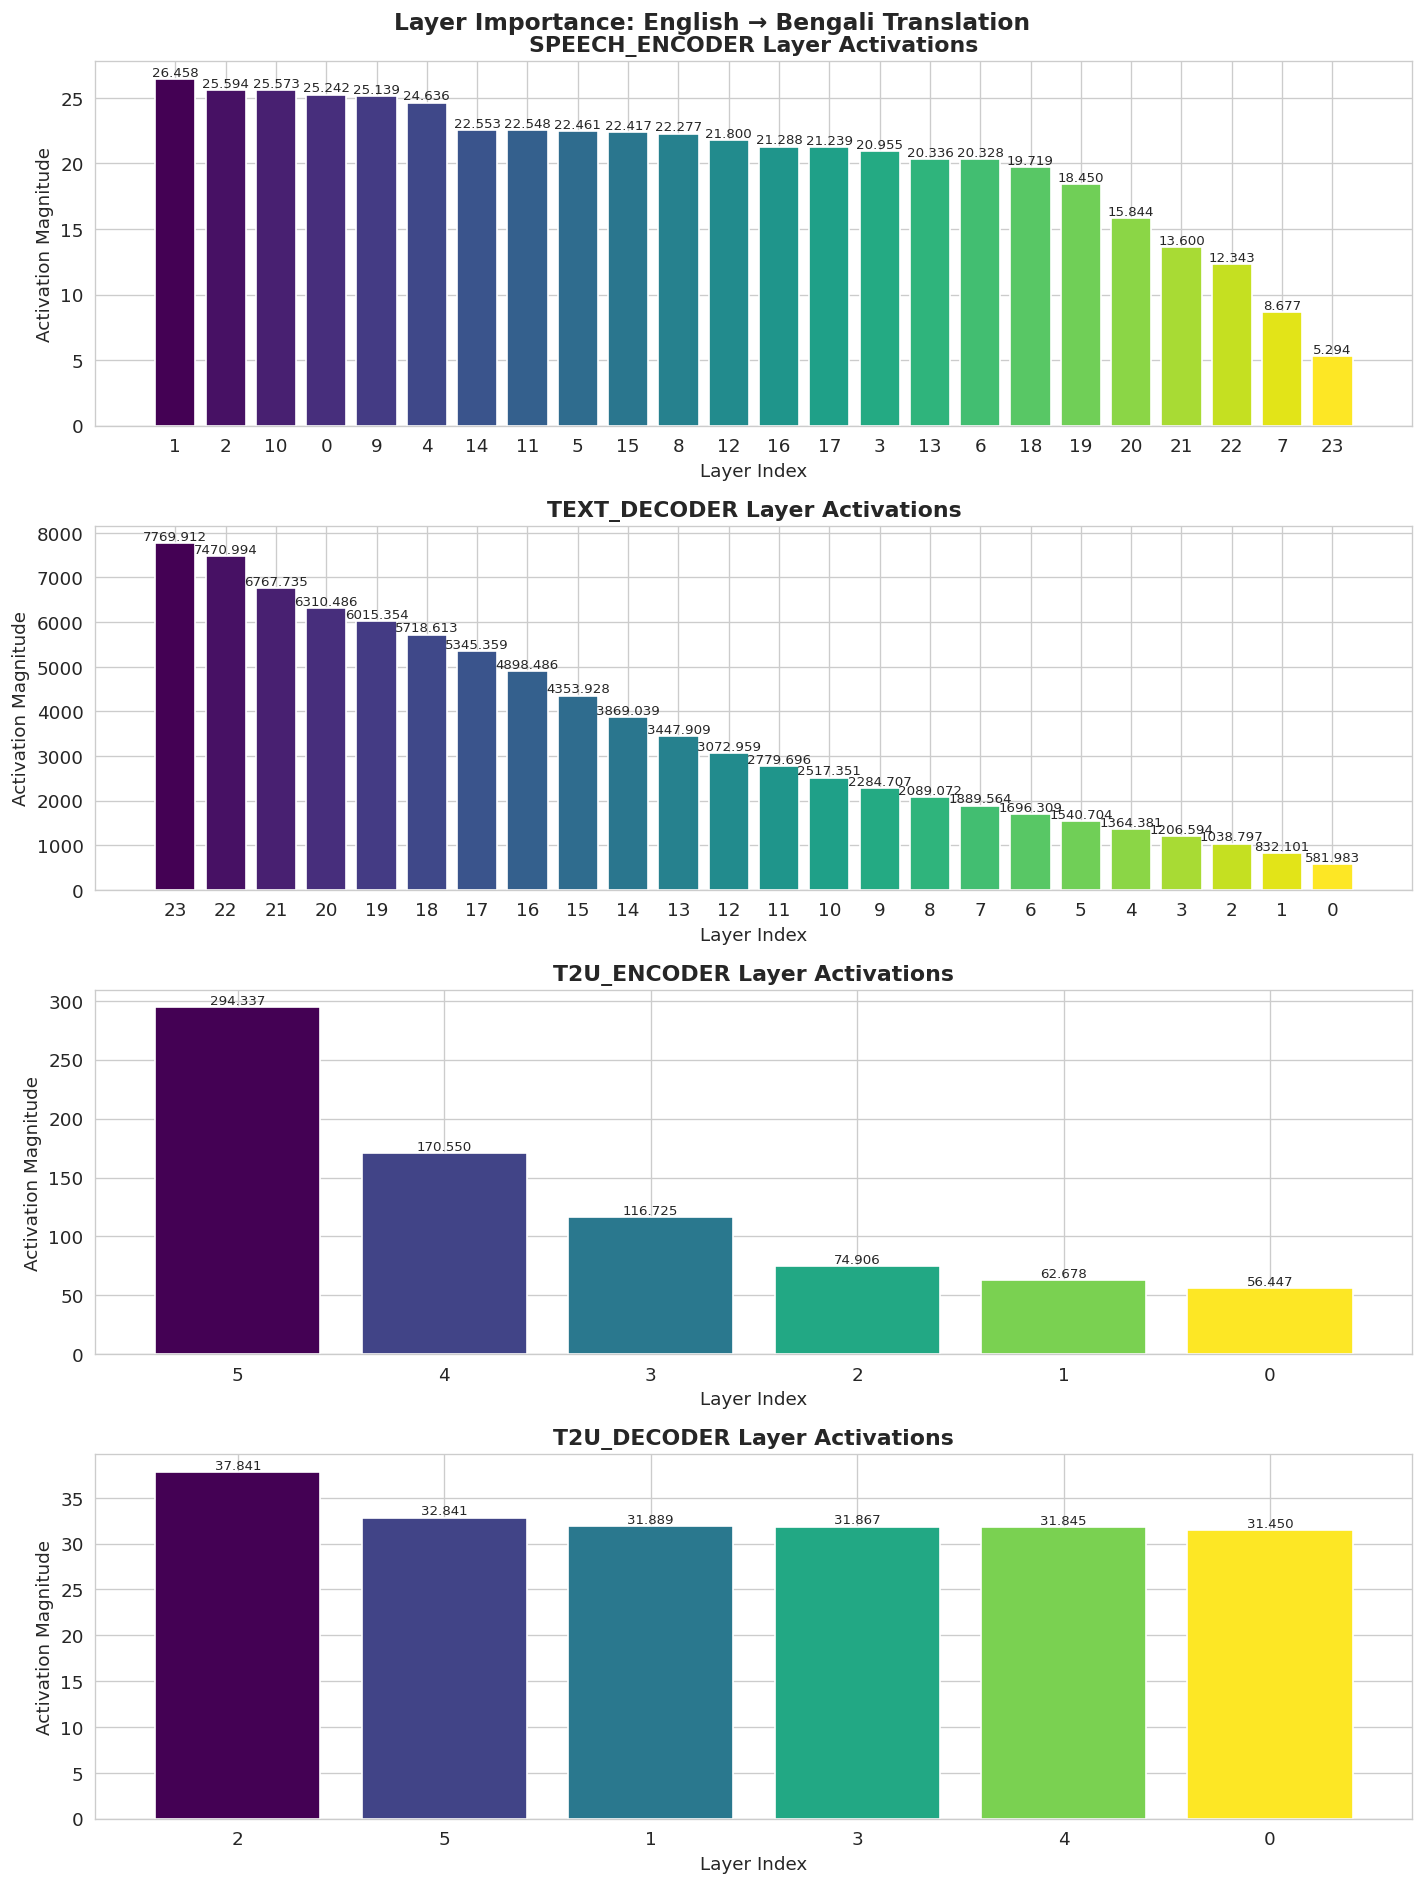

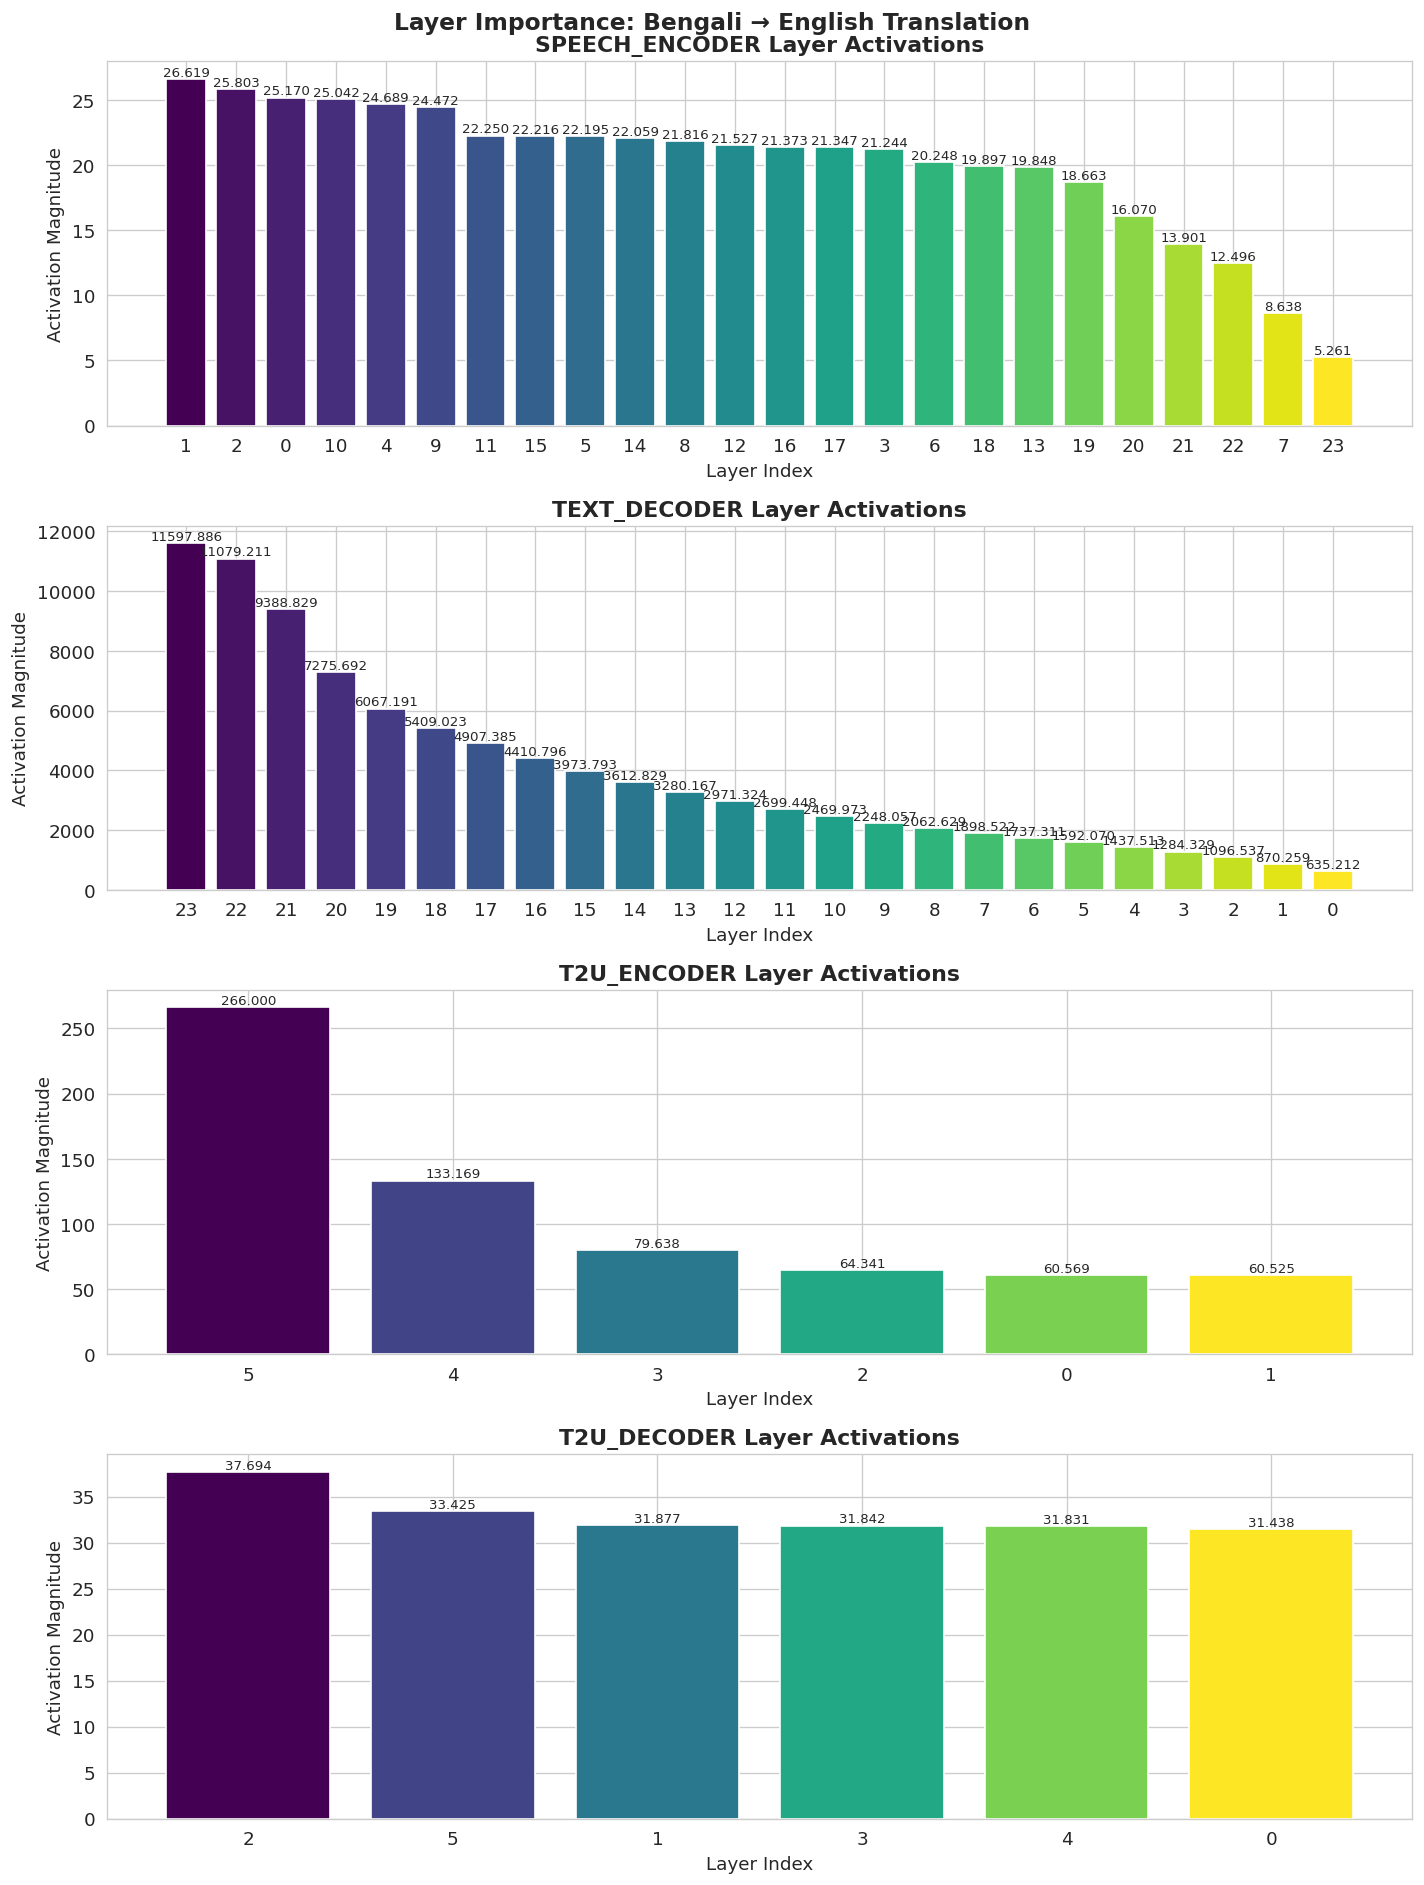

In [32]:
# ===============================================================================
# VISUALIZATION
# ===============================================================================

print("\nGenerating layer importance visualizations...")

def plot_layer_activations(rankings_dict, title, save_name):
    """Plot layer activation patterns"""
    fig, axes = plt.subplots(len(rankings_dict), 1, 
                           figsize=(12, 4 * len(rankings_dict)))
    if len(rankings_dict) == 1:
        axes = [axes]
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    for i, (component, layer_data) in enumerate(rankings_dict.items()):
        ax = axes[i]
        
        if not layer_data:
            continue
            
        layers, activations = zip(*layer_data)
        
        # Create color map based on importance
        colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
        
        bars = ax.bar(range(len(layers)), activations, color=colors)
        ax.set_title(f'{component.upper()} Layer Activations', fontweight='bold')
        ax.set_xlabel('Layer Index')
        ax.set_ylabel('Activation Magnitude')
        ax.set_xticks(range(len(layers)))
        ax.set_xticklabels([str(l) for l in layers])
        
        # Add value labels on bars
        for bar, act in zip(bars, activations):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                   f'{act:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()

# Plot for both directions
if eng_to_ben_rankings:
    plot_layer_activations(eng_to_ben_rankings, 
                          'Layer Importance: English → Bengali Translation',
                          'layer_importance_en_to_bn.png')

if ben_to_eng_rankings:
    plot_layer_activations(ben_to_eng_rankings,
                          'Layer Importance: Bengali → English Translation', 
                          'layer_importance_bn_to_en.png')

Creating comparative heatmap...


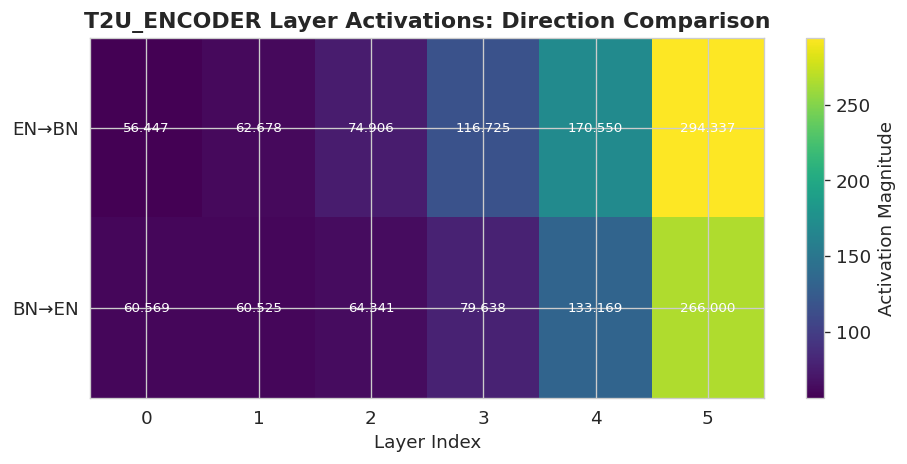

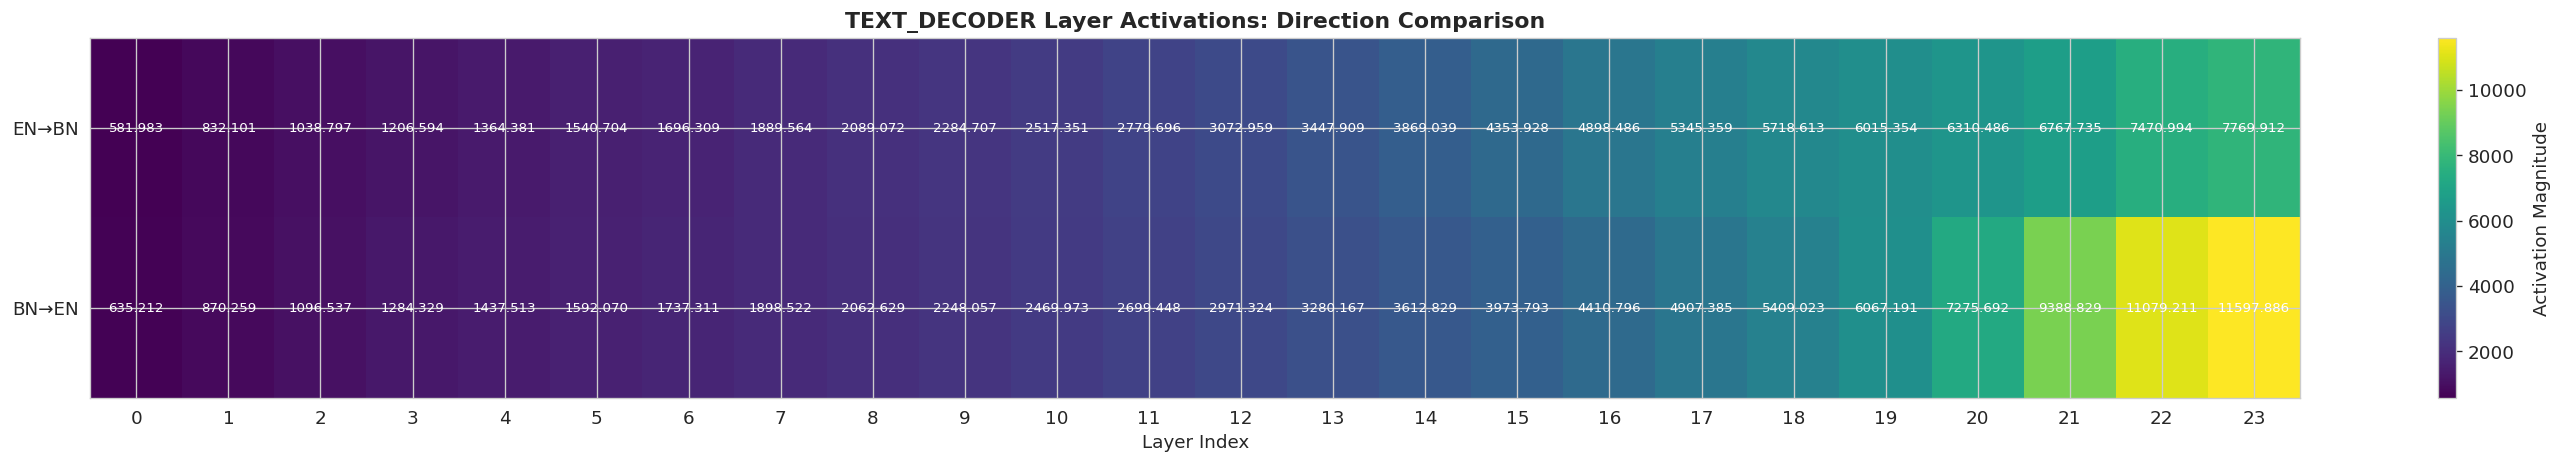

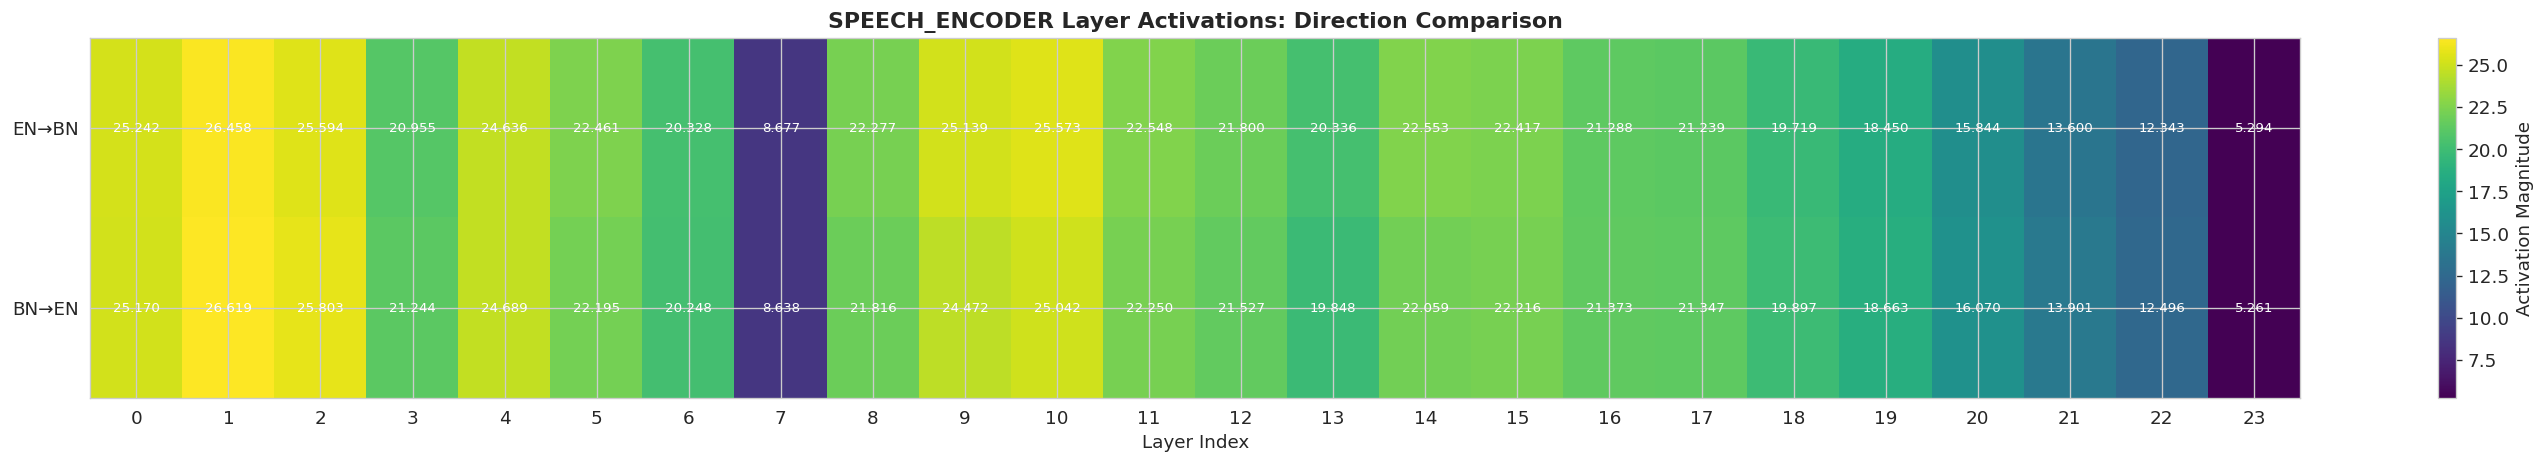

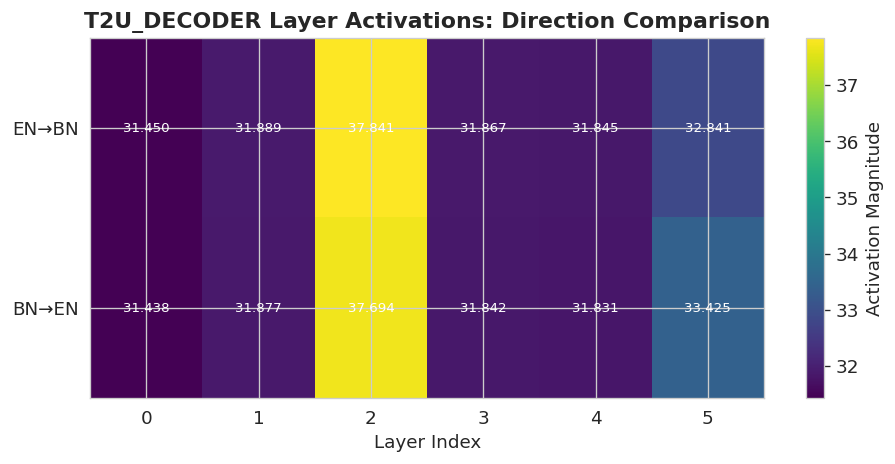


  BIDIRECTIONAL ANALYSIS COMPLETE
Layer importance rankings and visualizations have been generated.
Check the figures directory for detailed plots.


43623

In [33]:
# Comparative heatmap
if eng_to_ben_rankings and ben_to_eng_rankings:
    print("Creating comparative heatmap...")
    
    # Find common components
    common_components = set(eng_to_ben_rankings.keys()) & set(ben_to_eng_rankings.keys())
    
    for component in common_components:
        layers1 = dict(eng_to_ben_rankings[component])
        layers2 = dict(ben_to_eng_rankings[component])
        all_layers = sorted(set(layers1.keys()) | set(layers2.keys()))
        
        if len(all_layers) < 2:
            continue
            
        # Create comparison matrix
        data = np.zeros((2, len(all_layers)))
        for i, layer_idx in enumerate(all_layers):
            data[0, i] = layers1.get(layer_idx, 0.0)  # EN→BN
            data[1, i] = layers2.get(layer_idx, 0.0)  # BN→EN
        
        fig, ax = plt.subplots(figsize=(max(8, len(all_layers)), 4))
        im = ax.imshow(data, cmap='viridis', aspect='auto')
        
        ax.set_title(f'{component.upper()} Layer Activations: Direction Comparison', 
                    fontweight='bold')
        ax.set_xlabel('Layer Index')
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['EN→BN', 'BN→EN'])
        ax.set_xticks(range(len(all_layers)))
        ax.set_xticklabels([str(l) for l in all_layers])
        
        # Add text annotations
        for i in range(2):
            for j in range(len(all_layers)):
                text = ax.text(j, i, f'{data[i, j]:.3f}',
                             ha="center", va="center", color="white", fontsize=8)
        
        plt.colorbar(im, ax=ax, label='Activation Magnitude')
        plt.tight_layout()
        save_figure(fig, f'layer_comparison_{component}.png')
        plt.show()

print("\n" + "="*80)
print("  BIDIRECTIONAL ANALYSIS COMPLETE")
print("="*80)
print("Layer importance rankings and visualizations have been generated.")
print("Check the figures directory for detailed plots.")

# Clean up memory
del model_analysis
torch.cuda.empty_cache()
gc.collect()